# ViewSymReg

This notebook views the results from running symbolic regression. Test 5 uses the full feature set with z-score standardization. Test 8 uses the length, amounts of each bead type and fractions of each bead type as the feature set. No pre-processing is done. Test 7 uses the length and amounts of each bead type as the feature set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.pyplot import figure

# Read the data and define feature sets

In [2]:
features1 = [
    "num_[W]",
    "max_[W]",
    "num_[Tr]",
    "max_[Tr]",
    "num_[Ta]",
    "max_[Ta]",
    "num_[R]",
    "max_[R]",
    "[W]",
    "[Tr]",
    "[Ta]",
    "[R]",
    "rel_shannon",
    "length",
]
features2 = [
    "length",
    "total_[W]",
    "total_[Tr]",
    "total_[Ta]",
    "total_[R]",
    "[W]",
    "[Tr]",
    "[Ta]",
    "[R]",
]
features3 = ["length", "total_[W]", "total_[Tr]", "total_[Ta]", "total_[R]"]

df1 = pd.read_csv("symreg/Test1_fold0.csv")
df2 = pd.read_csv("symreg/Test2_totals_fracs_fold0.csv")
df3 = pd.read_csv("symreg/Test3_totals_fold0.csv")

# Look at results

In [3]:
def computemask(equations):
    """Determine if complex operators are in the equation. If so, return True."""

    operators = ["exp", "sin", "tanh", "log", "square", "cube"]
    maskunit = np.zeros(len(equations)).astype(bool)

    for i, equation in enumerate(equations):
        for operator in operators:
            if operator in equation:
                maskunit[i] = True
    return maskunit

In [4]:
maskunit1 = computemask(df1["equation"])

for i in range(len(df1)):
    print(i, maskunit1[i], df1.iloc[i]["complexity"], df1.iloc[i]["equation"])

0 False 1 11.822941
1 False 3 11.82268 - x8
2 True 4 13.492414 - exp(x8)
3 False 5 (x13 - x8) + 11.8227215
4 False 7 ((x13 + x11) - x8) + 11.822957
5 False 9 ((x13 + (5.8640833 - x8)) - x9) * 2.0160742
6 True 10 ((x13 + (5.2789335 - x8)) - tanh(x9)) * 2.2356825
7 False 11 (x10 + (((x13 + x11) / 0.5544794) - x8)) - -11.822475
8 True 12 (log(x11 - -4.2910056) * ((x13 + x10) + 8.338036)) - x8
9 False 13 (((x11 - -5.491485) * (x13 + (x10 + 7.6294947))) * 0.28450793) - x8
10 True 14 ((x11 - -5.4725995) * cube(((x13 + x10) * 0.05797033) + 1.2911245)) - x8
11 False 15 ((((x10 * 0.8058213) + x11) - -3.7228515) * ((x13 * 0.45432782) + 3.1756742)) + x9
12 False 17 ((x13 * 0.32314655) + 2.2395232) * (x11 + ((x10 * 0.7203747) - ((x8 * 0.3817063) - 5.2780437)))
13 True 18 ((x13 * 0.3247824) + 2.2410219) * (x11 + ((x10 * 0.72038347) - (sin(x8 / 2.4689906) - 5.2731614)))
14 False 19 (x1 + (((x11 + (x10 * 0.72090113)) - ((x8 / 2.1164813) - 5.3012247)) * (x13 + 7.184107))) * 0.31040946
15 True 20 (tanh

In [5]:
maskunit2 = computemask(df2["equation"])

for i in range(len(df2)):
    print(i, maskunit2[i], df2.iloc[i]["complexity"], df2.iloc[i]["equation"])

0 False 1 11.821991
1 False 3 x4 + 3.8640199
2 False 5 (x7 * 16.178429) + x4
3 True 6 (x3 / log(x1)) + x4
4 False 7 (x3 + x4) / (x5 + 1.1163858)
5 True 8 (x4 + (x3 / 1.1642826)) / exp(x5)
6 False 9 ((x3 / 1.4339507) + x4) / (x5 + 0.9135293)
7 True 10 exp(x1 * -0.023814317) * ((x3 * 0.784796) + x4)
8 False 11 ((x1 * -0.02351936) + 1.0561297) * (x4 + (x3 * 0.70766556))
9 True 12 (x1 * -0.3412415) + (x4 + ((x3 * 0.63641036) - log(x8)))
10 False 13 (((x3 * 0.6381865) + 2.2929347) + (x4 * 0.893578)) + (x1 * -0.33932036)
11 False 15 (((x1 + x5) * -0.33140454) + ((x4 * 0.8909435) + 2.3546584)) + (x3 * 0.6355384)
12 True 16 ((x3 * 0.6400891) + ((cube(x8) + (x4 * 0.8888182)) + 2.2803378)) + (x1 * -0.33742842)
13 False 17 ((x1 * -0.3074579) + (((x3 * 0.6381327) - x5) + ((x4 + 2.6612732) * 0.86172676))) + x8
14 True 18 x8 + ((((x4 + (x3 / 1.3520921)) + (x1 * -0.34708548)) / (cube(x5) + 1.1476817)) + 2.0143237)
15 True 19 (exp(x8) + 0.99212587) + (((((x1 * -0.46381074) + x3) / 1.3361089) + x4) / (

In [6]:
maskunit3 = computemask(df3["equation"])

for i in range(len(df3)):
    print(i, maskunit3[i], df3.iloc[i]["complexity"], df3.iloc[i]["equation"])

0 False 1 11.822719
1 False 3 x4 + 3.863965
2 False 5 (x4 + x3) / 1.3493412
3 True 6 x4 + (x3 / log(x1))
4 True 8 (x3 / log(x1)) + (x4 / 1.0491613)
5 False 9 (x1 * -0.2543655) + (x4 + (x3 * 0.7233712))
6 True 10 ((x3 / 1.274302) + x4) / exp(x1 * 0.02381276)
7 False 11 (x4 + (x3 * 0.70767504)) * (1.0561274 - (x1 * 0.02351933))
8 True 12 (x4 + (x3 * 0.670717)) / exp((x1 + -3.7572947) / x0)
9 False 13 (x4 * 0.89389944) + (((x3 * 0.6383574) + (x1 * -0.3394439)) + 2.2890625)
10 False 15 (((x1 * -0.33941498) + (x3 * 0.6378789)) + 33050.406) + ((x4 * 0.89390683) - 33048.113)
11 True 16 (((x4 + (x3 * 0.7529647)) + ((x1 - log(x4)) * -0.40036374)) * 0.84753984) - -1.9796356
12 False 17 ((0.9151738 - (x1 * 0.0027115876)) * ((x3 * 0.7141907) + x4)) + ((x1 * -0.3021712) - -1.9971982)
13 True 18 (0.8935139 - sin(x0 * 1.5708704)) * ((x4 + (x1 * -0.37960038)) + ((x3 * 0.7142562) - -2.5656536))
14 True 20 (((x3 * 0.7152672) + (x4 - -2.5600665)) * 0.89356875) + (x1 * (-0.33967263 - (sin(x2 - x3) * -0.00

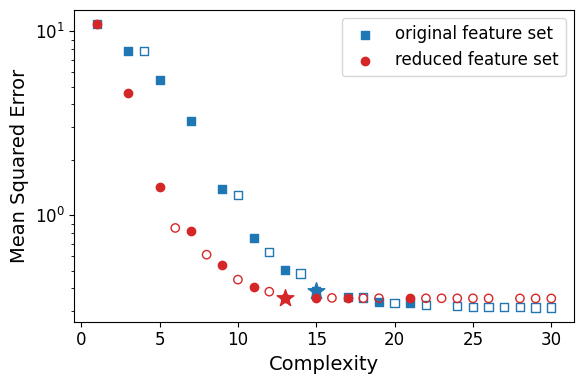

In [7]:
figure(figsize=(6, 4))

plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14

plt.scatter(
    df1["complexity"].iloc[maskunit1],
    df1.iloc[maskunit1]["loss"],
    facecolors="none",
    edgecolors="tab:blue",
    marker="s",
)
plt.scatter(
    df1["complexity"].iloc[np.logical_not(maskunit1)],
    df1.iloc[np.logical_not(maskunit1)]["loss"],
    facecolors="tab:blue",
    edgecolors="tab:blue",
    marker="s",
    label="original feature set",
)
plt.scatter(
    df1.iloc[11]["complexity"],
    df1.iloc[11]["loss"],
    marker="*",
    color="tab:blue",
    s=160,
)

plt.scatter(
    df2.iloc[maskunit2]["complexity"],
    df2.iloc[maskunit2]["loss"],
    facecolors="none",
    edgecolors="tab:red",
    marker="o",
)
plt.scatter(
    df2.iloc[np.logical_not(maskunit2)]["complexity"],
    df2.iloc[np.logical_not(maskunit2)]["loss"],
    facecolors="tab:red",
    edgecolors="tab:red",
    marker="o",
    label="reduced feature set",
)
plt.scatter(
    df2.iloc[10]["complexity"], df2.iloc[10]["loss"], marker="*", color="tab:red", s=160
)

# plt.scatter(df3.iloc[maskunit3]['complexity'],df3.iloc[maskunit3]['loss'],facecolors='none', edgecolors='tab:red',marker='o')
# plt.scatter(df3.iloc[np.logical_not(maskunit3)]['complexity'],df3.iloc[np.logical_not(maskunit3)]['loss'],facecolors='tab:red', edgecolors='tab:red',marker='o', label='reduced feature set')
# plt.scatter(df3.iloc[9]['complexity'],df3.iloc[9]['loss'],marker='*',color='tab:red',s=160)

plt.yscale("log")
plt.legend()
plt.ylabel("Mean Squared Error")
plt.xlabel("Complexity")

plt.tight_layout()
plt.savefig("figures/loss_complexity.jpg", dpi=600)

# View the best equations

Note Test 2 and Test 3 give virtually the same best equation.

In [8]:
print(df1.iloc[11]["equation"])
for i, f in enumerate(features1):
    print("x" + str(i) + " = ", f)

((((x10 * 0.8058213) + x11) - -3.7228515) * ((x13 * 0.45432782) + 3.1756742)) + x9
x0 =  num_[W]
x1 =  max_[W]
x2 =  num_[Tr]
x3 =  max_[Tr]
x4 =  num_[Ta]
x5 =  max_[Ta]
x6 =  num_[R]
x7 =  max_[R]
x8 =  [W]
x9 =  [Tr]
x10 =  [Ta]
x11 =  [R]
x12 =  rel_shannon
x13 =  length


In [9]:
print(df2.iloc[10]["loss"])
print(df2.iloc[10]["equation"])
for i, f in enumerate(features2):
    print("x" + str(i) + " = ", f)

0.35520342
(((x3 * 0.6381865) + 2.2929347) + (x4 * 0.893578)) + (x1 * -0.33932036)
x0 =  length
x1 =  total_[W]
x2 =  total_[Tr]
x3 =  total_[Ta]
x4 =  total_[R]
x5 =  [W]
x6 =  [Tr]
x7 =  [Ta]
x8 =  [R]


In [10]:
print(df3.iloc[9]["loss"])
print(df3.iloc[9]["equation"])
for i, f in enumerate(features3):
    print("x" + str(i) + " = ", f)

0.3551499
(x4 * 0.89389944) + (((x3 * 0.6383574) + (x1 * -0.3394439)) + 2.2890625)
x0 =  length
x1 =  total_[W]
x2 =  total_[Tr]
x3 =  total_[Ta]
x4 =  total_[R]
